<a href="https://colab.research.google.com/github/ecoresearchiq/Fiscal/blob/main/Sector_Fiscal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sector Fiscal: ejecución del gasto municipal por función (MEF, Consulta Amigable)
Insumos (scrapeados por los notebooks `BI_*` en `Fiscal/Scrapeo/`):
- `Fiscal/Scrapeo/output/DEV/`: devengado **mensual** (flujo del mes) por función y municipalidad, un CSV por mes.
- `Fiscal/Scrapeo/output/PIM/`: PIM anual por función y nivel de gobierno (GN, GR, GL), un CSV por año.
- `Fiscal/Procesamiento/input/IPC.xlsx`: IPC Lima (INEI, Dic.2021 = 100), para expresar el gasto en soles constantes.

Resultados en `Fiscal/Procesamiento/output/`:
- `Fiscal_<Depto>_<AAAAMM>.xlsx` (Loreto, San Martín, Ucayali) y `Fiscal_Consolidado_<AAAAMM>.xlsx`.
- `REPORTE_<AAAAMM>.txt` con el resumen del mes y las advertencias sobre los insumos.
- Gráficos `f1`..`f4` por departamento en PNG y `panel_devengado_municipal.csv` (todo el panel).

Cada corrida procesa todos los CSV disponibles; el mes de reporte es el último del panel (o `MES_REPORTE`).

In [17]:
# 1. Montar Drive y definir rutas
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os

SECTOR = 'Fiscal'
BASE_SECTOR = f'/content/drive/My Drive/{SECTOR}'
DEV_DIR  = os.path.join(BASE_SECTOR, 'Scrapeo', 'output', 'DEV')
PIM_DIR  = os.path.join(BASE_SECTOR, 'Scrapeo', 'output', 'PIM')
PROC_IN  = os.path.join(BASE_SECTOR, 'Procesamiento', 'input')
PROC_OUT = os.path.join(BASE_SECTOR, 'Procesamiento', 'output')
os.makedirs(PROC_OUT, exist_ok=True)
os.chdir(BASE_SECTOR)

print("Directorio actual:", os.getcwd())
for etiqueta, ruta in [('DEV', DEV_DIR), ('PIM', PIM_DIR), ('Procesamiento/input', PROC_IN)]:
    print(f"\n{etiqueta}:")
    for nombre in sorted(os.listdir(ruta)):
        print(" -", nombre)

Mounted at /content/drive
Directorio actual: /content/drive/My Drive/Fiscal

DEV:
 - DEV Funcion.Municipalidad 2025 - Mes 01 - LOR - SMN - UCA.csv
 - DEV Funcion.Municipalidad 2025 - Mes 02 - LOR - SMN - UCA.csv
 - DEV Funcion.Municipalidad 2025 - Mes 03 - LOR - SMN - UCA.csv
 - DEV Funcion.Municipalidad 2025 - Mes 04 - LOR - SMN - UCA.csv
 - DEV Funcion.Municipalidad 2025 - Mes 05 - LOR - SMN - UCA.csv
 - DEV Funcion.Municipalidad 2025 - Mes 06 - LOR - SMN - UCA.csv
 - DEV Funcion.Municipalidad 2025 - Mes 07 - LOR - SMN - UCA.csv
 - DEV Funcion.Municipalidad 2025 - Mes 08 - LOR - SMN - UCA.csv
 - DEV Funcion.Municipalidad 2025 - Mes 09 - LOR - SMN - UCA.csv
 - DEV Funcion.Municipalidad 2025 - Mes 10 - LOR - SMN - UCA.csv
 - DEV Funcion.Municipalidad 2025 - Mes 11 - LOR - SMN - UCA.csv
 - DEV Funcion.Municipalidad 2025 - Mes 12 - LOR - SMN - UCA.csv
 - DEV Funcion.Municipalidad 2026 - Mes 01 - LOR - SMN - UCA.csv
 - DEV Funcion.Municipalidad 2026 - Mes 02 - LOR - SMN - UCA.csv
 - DEV F

In [18]:
# 2. Librerías y parámetros
!pip install -q openpyxl
import re, glob, unicodedata, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.1f}'.format)

MESES_ES = ['enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio', 'julio', 'agosto', 'setiembre', 'octubre', 'noviembre', 'diciembre']
DEPARTAMENTOS = {'LORETO': 'Loreto', 'SAN MARTIN': 'San Martín', 'UCAYALI': 'Ucayali'}   # clave sin tilde, como en el panel
MES_REPORTE  = None          # None = último mes del panel; o 'AAAA-MM' para reprocesar un mes anterior
MES_BASE_IPC = None          # None = mes de reporte (soles constantes de ese mes); o 'AAAA-MM'
UNIDAD = 1e6                 # divisor para los cuadros: 1e6 = millones de soles
ADVERTENCIAS = []


def clave(x):
    s = unicodedata.normalize('NFKD', str(x)).encode('ascii', 'ignore').decode().upper()
    return re.sub(r'\s+', ' ', s).strip()


def sin_codigo(x):
    """'16: LORETO' -> 'LORETO'; '03: PLANEAMIENTO...' -> 'PLANEAMIENTO...'"""
    return re.sub(r'^\s*[\w-]+\s*:\s*', '', str(x)).strip()


def codigo(x):
    """'16: LORETO' -> '16'; '160101-301422: MUNICIPALIDAD ...' -> '160101-301422'"""
    m = re.match(r'^\s*([\w-]+)\s*:', str(x))
    return m.group(1) if m else None

In [19]:
# 3. Devengado mensual por función y municipalidad (DEV)
def leer_dev(path):
    d = pd.read_csv(path, encoding='utf-8-sig', dtype=str)
    d.columns = [clave(c) for c in d.columns]
    esperadas = {'ANO', 'MES', 'DEPARTAMENTO', 'FUNCION', 'MUNICIPALIDAD', 'DEVENGADO'}
    assert esperadas <= set(d.columns), f'{os.path.basename(path)}: columnas {list(d.columns)}'
    out = pd.DataFrame({
        'anio': d['ANO'].astype(int),
        'mes': d['MES'].str.extract(r'^\s*(\d+)')[0].astype(int),
        'departamento': d['DEPARTAMENTO'].map(sin_codigo).map(clave),
        'cod_funcion': d['FUNCION'].map(codigo),
        'funcion': d['FUNCION'].map(sin_codigo).str.title(),
        'cod_muni': d['MUNICIPALIDAD'].map(codigo),
        'municipalidad': d['MUNICIPALIDAD'].map(sin_codigo).str.title(),
        'devengado': pd.to_numeric(d['DEVENGADO'].str.replace(',', '', regex=False).str.strip(), errors='coerce'),
    })
    out['fecha'] = pd.to_datetime(dict(year=out['anio'], month=out['mes'], day=1)) + pd.offsets.MonthEnd(0)
    out['ubigeo'] = out['cod_muni'].str.split('-').str[0]
    out['tipo_muni'] = np.where(out['municipalidad'].str.contains('Provincial', case=False), 'Provincial', 'Distrital')
    out['archivo'] = os.path.basename(path)
    return out

archivos_dev = sorted(glob.glob(os.path.join(DEV_DIR, '*.csv')))
archivos_err = [f for f in archivos_dev if 'ERROR' in os.path.basename(f).upper()]
archivos_dev = [f for f in archivos_dev if f not in archivos_err]
assert archivos_dev, 'No hay CSV de devengado en Scrapeo/output/DEV'
dev = pd.concat([leer_dev(f) for f in archivos_dev], ignore_index=True)
dev = dev.drop_duplicates(['fecha', 'departamento', 'cod_funcion', 'cod_muni'], keep='last')

# provincia: nombre de la municipalidad provincial con el mismo prefijo de ubigeo (4 dígitos)
prov = (dev[dev['tipo_muni'] == 'Provincial'].drop_duplicates('ubigeo')
        .assign(prov4=lambda x: x['ubigeo'].str[:4],
                provincia=lambda x: x['municipalidad'].str.replace(r'(?i)municipalidad provincial (del|de la|de)\s*', '', regex=True)
                                                       .str.split(' - ').str[0].str.strip())
        .set_index('prov4')['provincia'])
dev['provincia'] = dev['ubigeo'].str[:4].map(prov).fillna('Provincia ' + dev['ubigeo'].str[:4])
dev['devengado'] = dev['devengado'].fillna(0.0)

# verificaciones
meses_panel = sorted(dev['fecha'].unique())
esperados = pd.date_range(meses_panel[0], meses_panel[-1], freq='ME')
faltan = [m.strftime('%Y-%m') for m in esperados if m not in set(meses_panel)]
if faltan:
    ADVERTENCIAS.append(f'Meses sin CSV de devengado dentro del rango: {", ".join(faltan)}.')
if archivos_err:
    ADVERTENCIAS.append('Hay archivos de ERRORES del scraping en DEV (peticiones fallidas): ' + ', '.join(os.path.basename(f) for f in archivos_err))
FECHA = pd.Timestamp(MES_REPORTE) + pd.offsets.MonthEnd(0) if MES_REPORTE else pd.Timestamp(meses_panel[-1])
assert FECHA in set(meses_panel), f'No hay devengado para {FECHA:%Y-%m}'
TAG = FECHA.strftime('%Y%m')
dev = dev[dev['fecha'] <= FECHA]
print(f"Devengado: {len(dev):,} filas | {pd.Timestamp(meses_panel[0]):%Y-%m} a {FECHA:%Y-%m} | "
      f"{dev['cod_muni'].nunique()} municipalidades | {dev['cod_funcion'].nunique()} funciones")
print(dev.groupby(['departamento', 'anio'])['devengado'].sum().unstack('anio') / UNIDAD)

Devengado: 13,455 filas | 2025-01 a 2026-09 | 151 municipalidades | 18 funciones
anio          2025  2026
departamento            
LORETO       765.3 641.2
SAN MARTIN   518.5 334.0
UCAYALI      254.4 208.6


In [20]:
# 4. PIM anual por función y nivel de gobierno (PIM)
def leer_pim(path):
    d = pd.read_csv(path, encoding='utf-8-sig', dtype=str)
    d.columns = [clave(c) for c in d.columns]
    return pd.DataFrame({
        'anio': d['ANO'].astype(int),
        'departamento': d['DEPARTAMENTO'].map(sin_codigo).map(clave),
        'nivel': d['NIVEL DE GOBIERNO'].map(clave).map({'GOBIERNO NACIONAL': 'GN', 'GOBIERNOS REGIONALES': 'GR', 'GOBIERNOS LOCALES': 'GL'}),
        'cod_funcion': d['FUNCION'].map(codigo),
        'funcion': d['FUNCION'].map(sin_codigo).str.title(),
        'pim': pd.to_numeric(d['PIM'].str.replace(',', '', regex=False), errors='coerce'),
    })

archivos_pim = sorted(glob.glob(os.path.join(PIM_DIR, '*.csv')))
pim = pd.concat([leer_pim(f) for f in archivos_pim], ignore_index=True) if archivos_pim else pd.DataFrame()
if len(pim):
    pim = pim.drop_duplicates(['anio', 'departamento', 'nivel', 'cod_funcion'], keep='last')
    if FECHA.year not in set(pim['anio']):
        ADVERTENCIAS.append(f'No hay PIM {FECHA.year}; no se calcula el avance de ejecución del año.')
    solo_dev = set(dev.loc[dev['anio'] == FECHA.year, 'cod_funcion']) - set(pim.loc[pim['anio'] == FECHA.year, 'cod_funcion'])
    if solo_dev:
        ADVERTENCIAS.append(f'Funciones con devengado pero sin PIM {FECHA.year}: {", ".join(sorted(solo_dev))}.')
    print(pim.pivot_table(index=['departamento', 'anio'], columns='nivel', values='pim', aggfunc='sum') / UNIDAD)
else:
    ADVERTENCIAS.append('No hay CSV de PIM en Scrapeo/output/PIM.')

nivel                  GL    GN      GR
departamento anio                      
LORETO       2025 1,023.9 344.7 1,066.6
             2026 1,417.1 373.7 1,111.3
SAN MARTIN   2025   687.3 376.9   679.8
             2026   641.2 300.6   619.5
UCAYALI      2025   402.3 205.4   504.0
             2026   449.9 136.3   700.4


In [21]:
# 5. IPC y deflactación (soles constantes del mes base)
def leer_ipc(path):
    t = pd.read_excel(path, sheet_name=0, header=None).dropna(how='all').dropna(axis=1, how='all')
    fechas = valores = None
    for c in t.columns:
        f = pd.to_datetime(t[c], errors='coerce')
        if f.notna().sum() >= 12 and (fechas is None or f.notna().sum() > fechas.notna().sum()): fechas = f
    for c in t.columns:
        v = pd.to_numeric(t[c], errors='coerce')
        if v.between(30, 500).sum() >= 12 and (valores is None or v.notna().sum() > valores.notna().sum()): valores = v
    assert fechas is not None and valores is not None, 'IPC.xlsx: no se identificaron las columnas de fecha e índice'
    s = pd.Series(valores.values, index=pd.to_datetime(fechas.values)).dropna()
    s.index = s.index + pd.offsets.MonthEnd(0)
    return s[~s.index.duplicated(keep='last')].sort_index()

ipc_archivo = next(iter(glob.glob(os.path.join(PROC_IN, '*IPC*.xls*'))), None)
assert ipc_archivo, 'No se encontró IPC.xlsx en Procesamiento/input'
ipc = leer_ipc(ipc_archivo)
BASE = (pd.Timestamp(MES_BASE_IPC) + pd.offsets.MonthEnd(0)) if MES_BASE_IPC else FECHA
if BASE not in ipc.index:
    BASE = ipc.index[ipc.index <= BASE].max()
    ADVERTENCIAS.append(f'El IPC no llega al mes de reporte; los valores reales se expresan en soles de {BASE:%Y-%m}.')
deflactor = ipc[BASE] / ipc
dev['devengado_real'] = dev['devengado'] * dev['fecha'].map(deflactor)
sin_ipc = sorted(dev.loc[dev['devengado_real'].isna(), 'fecha'].dt.strftime('%Y-%m').unique())
if sin_ipc:
    ADVERTENCIAS.append(f'Sin IPC para {", ".join(sin_ipc)}; esos meses quedan sin valor real.')
print(f"IPC: {ipc.index.min():%Y-%m} a {ipc.index.max():%Y-%m} | base {BASE:%Y-%m} = {ipc[BASE]:.2f} | "
      f"inflación 12 meses a {BASE:%Y-%m}: {100*(ipc[BASE]/ipc[BASE - pd.DateOffset(years=1) + pd.offsets.MonthEnd(0)]-1):.1f}%")
for a in ADVERTENCIAS:
    print('AVISO:', a)

IPC: 2010-01 a 2026-09 | base 2026-09 = 120.86 | inflación 12 meses a 2026-09: 4.5%


In [22]:
# 6. Cuadros por departamento
def variacion(a, b):
    return 100 * (a / b.replace(0, np.nan) - 1)

def cuadros(dkey):
    d = dev[dev['departamento'] == dkey]
    anio, mes = FECHA.year, FECHA.month
    f_ant = FECHA - pd.DateOffset(years=1) + pd.offsets.MonthEnd(0)
    actual_acum = d[(d['anio'] == anio) & (d['mes'] <= mes)]
    previo_acum = d[(d['anio'] == anio - 1) & (d['mes'] <= mes)]
    out = {}

    # --- mensual total y por función (nominal y real) ---
    out['Mensual total'] = (d.groupby('fecha')[['devengado', 'devengado_real']].sum() / UNIDAD).rename(
        columns={'devengado': 'nominal', 'devengado_real': f'real (S/ de {BASE:%b-%Y})'})
    out['Mensual por funcion'] = d.pivot_table(index='fecha', columns='funcion', values='devengado', aggfunc='sum', fill_value=0) / UNIDAD
    out['Mensual por funcion real'] = d.pivot_table(index='fecha', columns='funcion', values='devengado_real', aggfunc='sum', fill_value=0) / UNIDAD
    out['Mensual por provincia'] = d.pivot_table(index='fecha', columns='provincia', values='devengado', aggfunc='sum', fill_value=0) / UNIDAD

    # --- acumulado del año a la fecha vs mismo periodo del año anterior, por función ---
    def acum(df, key):
        return df.groupby(key)[['devengado', 'devengado_real']].sum()
    for key, nombre in [('funcion', 'Acumulado por funcion'), ('provincia', 'Acumulado por provincia'), ('municipalidad', 'Acumulado por municipalidad')]:
        a, b = acum(actual_acum, key), acum(previo_acum, key)
        t = pd.DataFrame({
            f'acum {anio-1} nominal': b['devengado'] / UNIDAD, f'acum {anio} nominal': a['devengado'] / UNIDAD,
            'var % nominal': variacion(a['devengado'], b['devengado']),
            f'acum {anio-1} real': b['devengado_real'] / UNIDAD, f'acum {anio} real': a['devengado_real'] / UNIDAD,
            'var % real': variacion(a['devengado_real'], b['devengado_real']),
        }).fillna({f'acum {anio-1} nominal': 0, f'acum {anio} nominal': 0})
        t['participación %'] = 100 * t[f'acum {anio} nominal'] / t[f'acum {anio} nominal'].sum()
        if key == 'municipalidad':
            extra = d.drop_duplicates('municipalidad').set_index('municipalidad')[['provincia', 'tipo_muni']]
            t = extra.join(t, how='right')
        out[nombre] = t.sort_values(f'acum {anio} nominal', ascending=False)

    # --- avance de ejecución del año: acumulado devengado GL / PIM GL, por función ---
    if len(pim) and anio in set(pim['anio']):
        p = pim[(pim['departamento'] == dkey) & (pim['anio'] == anio) & (pim['nivel'] == 'GL')].set_index('funcion')['pim']
        a = actual_acum.groupby('funcion')['devengado'].sum()
        av = pd.DataFrame({f'PIM {anio}': p / UNIDAD, f'devengado acum. {MESES_ES[mes-1]}': a / UNIDAD})
        av['avance %'] = 100 * av.iloc[:, 1] / av.iloc[:, 0].replace(0, np.nan)
        av.loc['TOTAL'] = [av.iloc[:, 0].sum(), av.iloc[:, 1].sum(), 100 * av.iloc[:, 1].sum() / av.iloc[:, 0].sum()]
        # avance a la misma altura del año anterior, si hay PIM del año anterior
        if anio - 1 in set(pim['anio']):
            p0 = pim[(pim['departamento'] == dkey) & (pim['anio'] == anio - 1) & (pim['nivel'] == 'GL')]['pim'].sum()
            av.loc['TOTAL', f'avance % {anio-1} mismo mes'] = 100 * previo_acum['devengado'].sum() / p0
        out['Avance PIM por funcion'] = av.sort_values(f'PIM {anio}', ascending=False)

    # --- PIM por nivel de gobierno y función, todos los años disponibles ---
    if len(pim):
        out['PIM por nivel y funcion'] = pim[pim['departamento'] == dkey].pivot_table(
            index='funcion', columns=['anio', 'nivel'], values='pim', aggfunc='sum', fill_value=0) / UNIDAD
        out['PIM por nivel y funcion'].loc['TOTAL'] = out['PIM por nivel y funcion'].sum()

    # --- resumen ---
    m_act, m_ant = d[d['fecha'] == FECHA], d[d['fecha'] == f_ant]
    res = [
        ('Mes de reporte', FECHA.strftime('%m/%Y')),
        ('Devengado del mes, mill. S/ (nominal)', m_act['devengado'].sum() / UNIDAD),
        (f'Var. interanual del mes, % nominal', variacion(pd.Series([m_act['devengado'].sum()]), pd.Series([m_ant['devengado'].sum()]))[0]),
        (f'Var. interanual del mes, % real', variacion(pd.Series([m_act['devengado_real'].sum()]), pd.Series([m_ant['devengado_real'].sum()]))[0]),
        (f'Devengado acumulado ene-{MESES_ES[mes-1][:3]} {anio}, mill. S/', actual_acum['devengado'].sum() / UNIDAD),
        (f'Var. acumulado vs ene-{MESES_ES[mes-1][:3]} {anio-1}, % nominal', variacion(pd.Series([actual_acum['devengado'].sum()]), pd.Series([previo_acum['devengado'].sum()]))[0]),
        (f'Var. acumulado vs ene-{MESES_ES[mes-1][:3]} {anio-1}, % real', variacion(pd.Series([actual_acum['devengado_real'].sum()]), pd.Series([previo_acum['devengado_real'].sum()]))[0]),
        ('Municipalidades con devengado en el mes', int((m_act.groupby('cod_muni')['devengado'].sum() > 0).sum())),
    ]
    if 'Avance PIM por funcion' in out:
        res += [(f'PIM GL {anio}, mill. S/', out['Avance PIM por funcion'].loc['TOTAL'].iloc[0]),
                (f'Avance de ejecución GL a {MESES_ES[mes-1]}, %', out['Avance PIM por funcion'].loc['TOTAL', 'avance %'])]
        if f'avance % {anio-1} mismo mes' in out['Avance PIM por funcion'].columns:
            res.append((f'Avance a {MESES_ES[mes-1]} {anio-1}, %', out['Avance PIM por funcion'].loc['TOTAL', f'avance % {anio-1} mismo mes']))
    out['Resumen'] = pd.DataFrame(res, columns=['Indicador', 'Valor'])
    return {'Resumen': out.pop('Resumen'), **out}

resultados = {dkey: cuadros(dkey) for dkey in DEPARTAMENTOS}
for dkey, dname in DEPARTAMENTOS.items():
    print(f'\n===== {dname} =====')
    print(resultados[dkey]['Resumen'].to_string(index=False))

# consolidado de los tres departamentos
consol = {}
tot = dev.groupby(['fecha', 'departamento'])[['devengado', 'devengado_real']].sum().unstack('departamento') / UNIDAD
consol['Mensual nominal'] = tot['devengado']; consol['Mensual real'] = tot['devengado_real']
consol['Resumen'] = pd.concat({DEPARTAMENTOS[k]: v['Resumen'].set_index('Indicador')['Valor'] for k, v in resultados.items()}, axis=1)
if len(pim):
    consol['PIM por nivel'] = pim.pivot_table(index=['departamento', 'nivel'], columns='anio', values='pim', aggfunc='sum') / UNIDAD


===== Loreto =====
                                 Indicador   Valor
                            Mes de reporte 09/2026
     Devengado del mes, mill. S/ (nominal)    82.3
        Var. interanual del mes, % nominal    44.3
           Var. interanual del mes, % real    38.0
Devengado acumulado ene-set 2026, mill. S/   641.2
 Var. acumulado vs ene-set 2025, % nominal    21.3
    Var. acumulado vs ene-set 2025, % real    16.7
   Municipalidades con devengado en el mes      52
                     PIM GL 2026, mill. S/ 1,417.1
     Avance de ejecución GL a setiembre, %    45.2
                Avance a setiembre 2025, %    51.6

===== San Martín =====
                                 Indicador   Valor
                            Mes de reporte 09/2026
     Devengado del mes, mill. S/ (nominal)    48.8
        Var. interanual del mes, % nominal    20.6
           Var. interanual del mes, % real    15.4
Devengado acumulado ene-set 2026, mill. S/   334.0
 Var. acumulado vs ene-set 2025, % nom

In [23]:
# 7. Exportar Excel y REPORTE
def exportar(nombre, hojas):
    ruta = os.path.join(PROC_OUT, nombre)
    with pd.ExcelWriter(ruta, engine='openpyxl') as w:
        for hoja, df in hojas.items():
            df.to_excel(w, sheet_name=hoja[:31], index=not (hoja == 'Resumen' and 'Indicador' in df.columns))
        pd.DataFrame({'Advertencia': ADVERTENCIAS or ['Ninguna']}).to_excel(w, sheet_name='Advertencias', index=False)
        from openpyxl.utils import get_column_letter
        for ws in w.book.worksheets:
            for j, col in enumerate(ws.iter_cols(min_row=1, max_row=ws.max_row), start=1):
                ancho = max((len(str(c.value)) for c in col if c.value is not None), default=8)
                ws.column_dimensions[get_column_letter(j)].width = min(50, max(10, ancho + 2))
    print('Guardado:', ruta)

for dkey, dname in DEPARTAMENTOS.items():
    exportar(f'Fiscal_{dname.replace(" ", "").replace("í", "i")}_{TAG}.xlsx', resultados[dkey])
exportar(f'Fiscal_Consolidado_{TAG}.xlsx', consol)
dev.drop(columns='archivo').to_csv(os.path.join(PROC_OUT, 'panel_devengado_municipal.csv'), index=False)

lineas = [f'REPORTE FISCAL {MESES_ES[FECHA.month-1].upper()} {FECHA.year}: gasto devengado de los gobiernos locales por función',
          f'(fuente: MEF Consulta Amigable; valores reales en soles de {BASE:%m/%Y} con IPC Lima)', '']
for dkey, dname in DEPARTAMENTOS.items():
    r = resultados[dkey]['Resumen'].set_index('Indicador')['Valor']
    lineas.append(f'{dname.upper()}:')
    for k, v in r.items():
        if isinstance(v, (int, np.integer)): lineas.append(f'  - {k}: {v:,d}')
        elif isinstance(v, (float, np.floating)): lineas.append(f'  - {k}: {v:,.1f}')
        else: lineas.append(f'  - {k}: {v}')
    top = resultados[dkey]['Acumulado por funcion'].head(3)
    lineas.append('  - Principales funciones (acumulado del año): ' + '; '.join(f'{i} {v:,.1f} mill. ({p:.0f}%)' for i, v, p in zip(top.index, top.iloc[:, 1], top['participación %'])))
    lineas.append('')
lineas += ['ADVERTENCIAS DE LOS INPUTS:'] + ([f'- {a}' for a in ADVERTENCIAS] or ['- Ninguna.'])
reporte = '\n'.join(lineas)
with open(os.path.join(PROC_OUT, f'REPORTE_{TAG}.txt'), 'w', encoding='utf-8') as fh:
    fh.write(reporte)
print(reporte)

Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/Fiscal_Loreto_202609.xlsx
Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/Fiscal_SanMartin_202609.xlsx
Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/Fiscal_Ucayali_202609.xlsx
Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/Fiscal_Consolidado_202609.xlsx
REPORTE FISCAL SETIEMBRE 2026: gasto devengado de los gobiernos locales por función
(fuente: MEF Consulta Amigable; valores reales en soles de 09/2026 con IPC Lima)

LORETO:
  - Mes de reporte: 09/2026
  - Devengado del mes, mill. S/ (nominal): 82.3
  - Var. interanual del mes, % nominal: 44.3
  - Var. interanual del mes, % real: 38.0
  - Devengado acumulado ene-set 2026, mill. S/: 641.2
  - Var. acumulado vs ene-set 2025, % nominal: 21.3
  - Var. acumulado vs ene-set 2025, % real: 16.7
  - Municipalidades con devengado en el mes: 52
  - PIM GL 2026, mill. S/: 1,417.1
  - Avance de ejecución GL a setiembre, %: 45.2
  - Avance a set

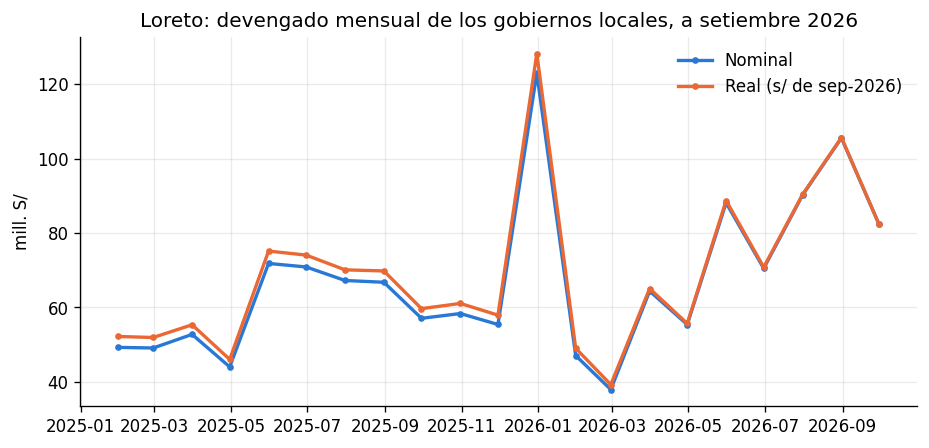

Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/f1_mensual_Loreto_202609.png


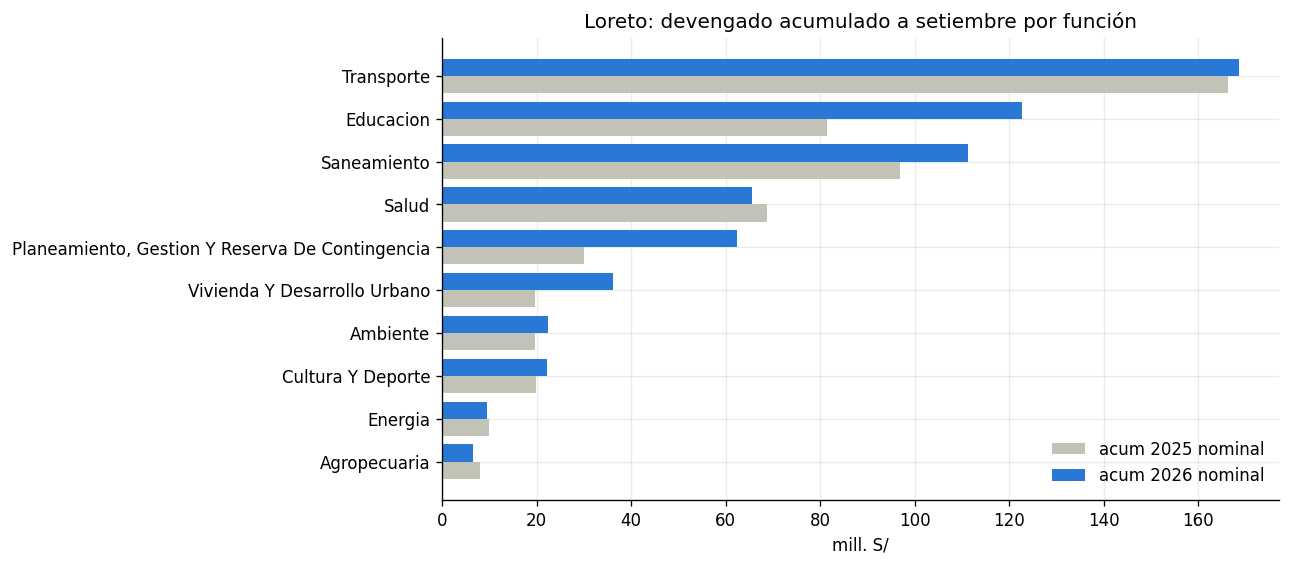

Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/f2_acumulado_funcion_Loreto_202609.png


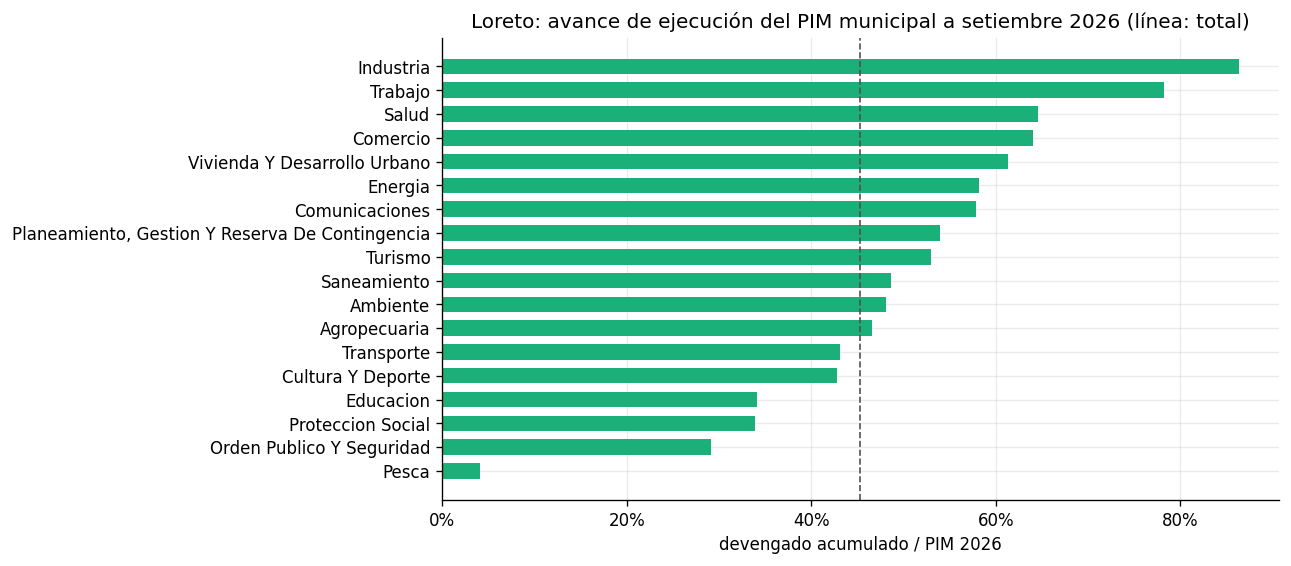

Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/f3_avance_pim_Loreto_202609.png


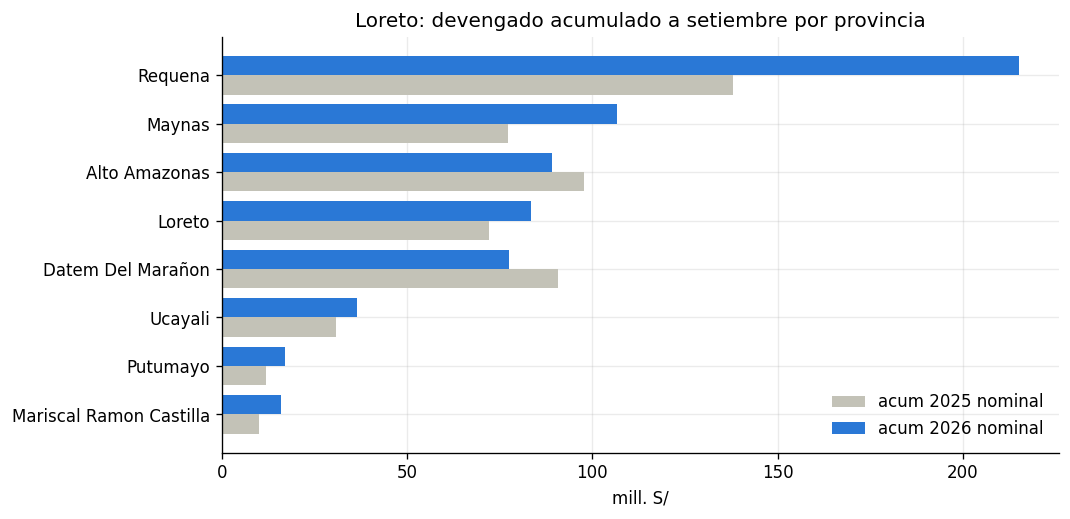

Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/f4_acumulado_provincia_Loreto_202609.png


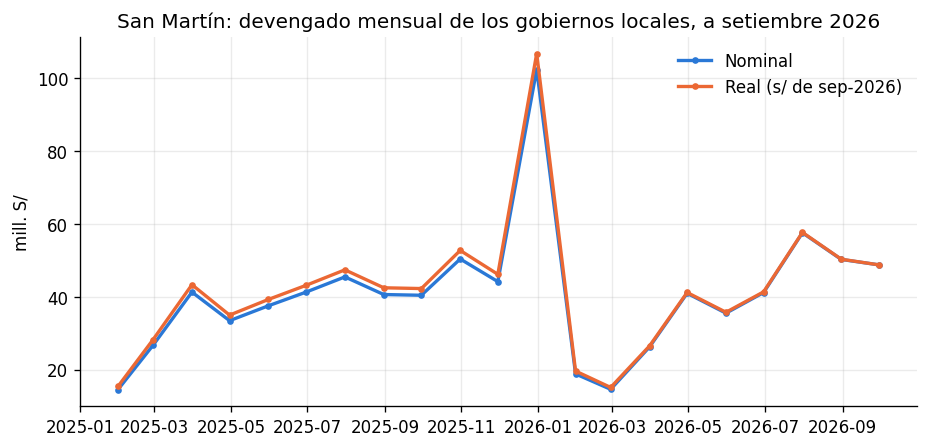

Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/f1_mensual_SanMartin_202609.png


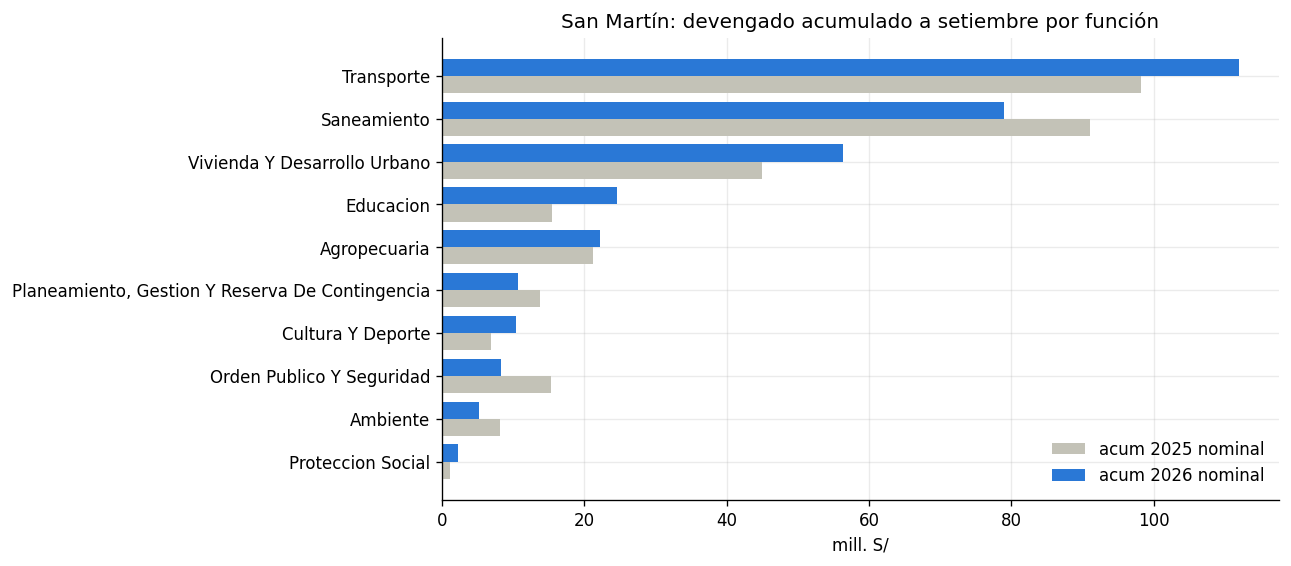

Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/f2_acumulado_funcion_SanMartin_202609.png


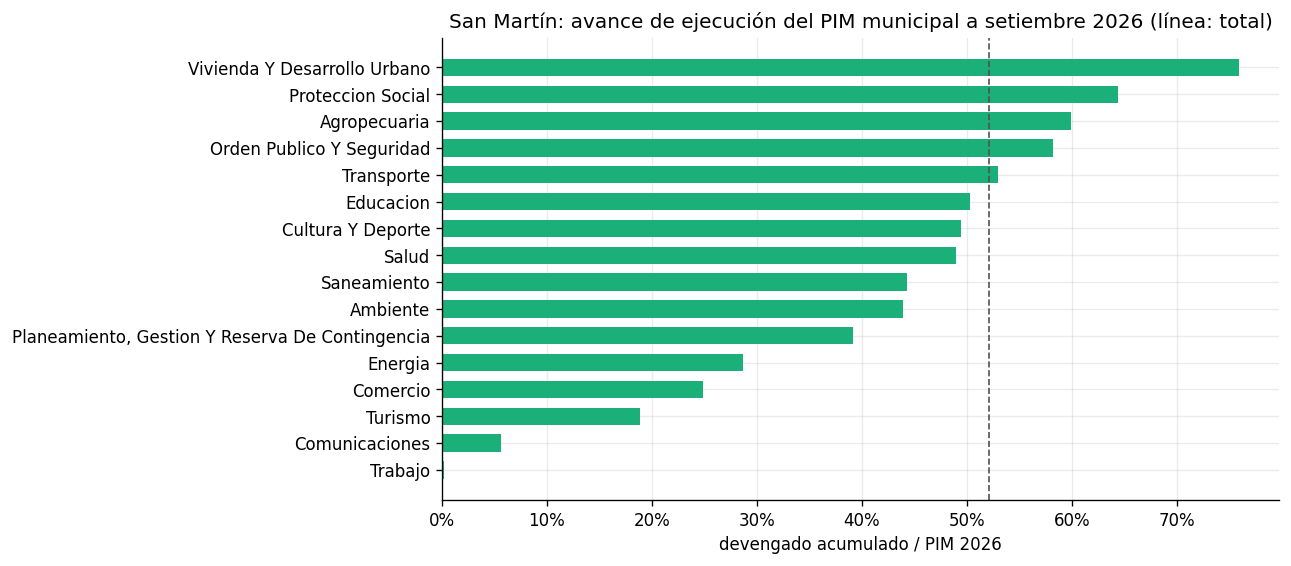

Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/f3_avance_pim_SanMartin_202609.png


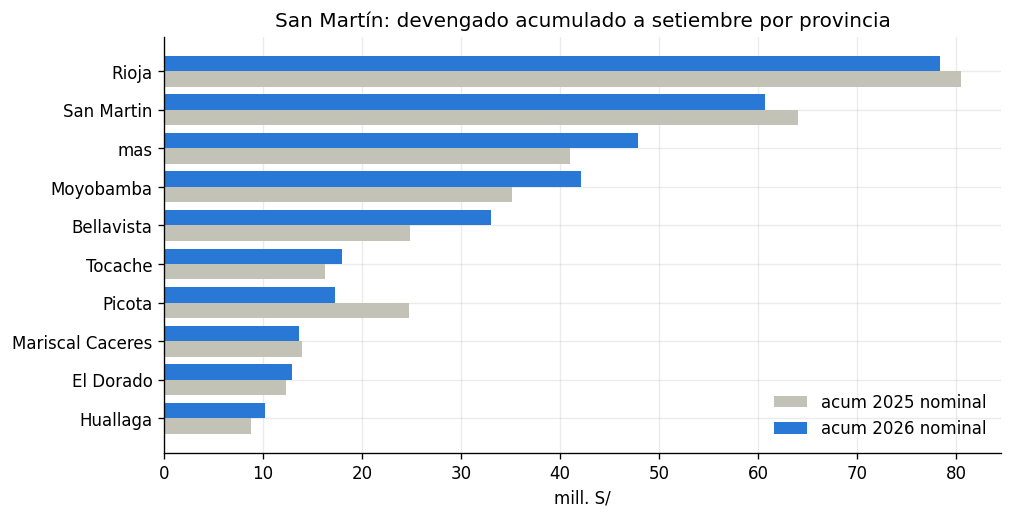

Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/f4_acumulado_provincia_SanMartin_202609.png


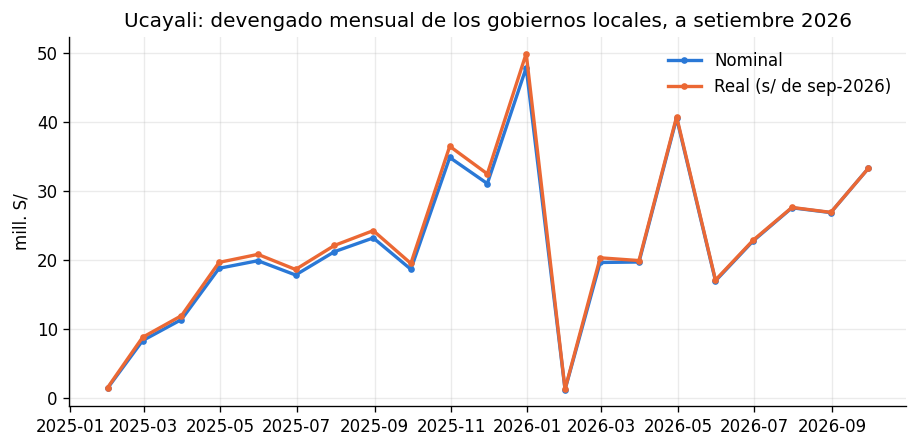

Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/f1_mensual_Ucayali_202609.png


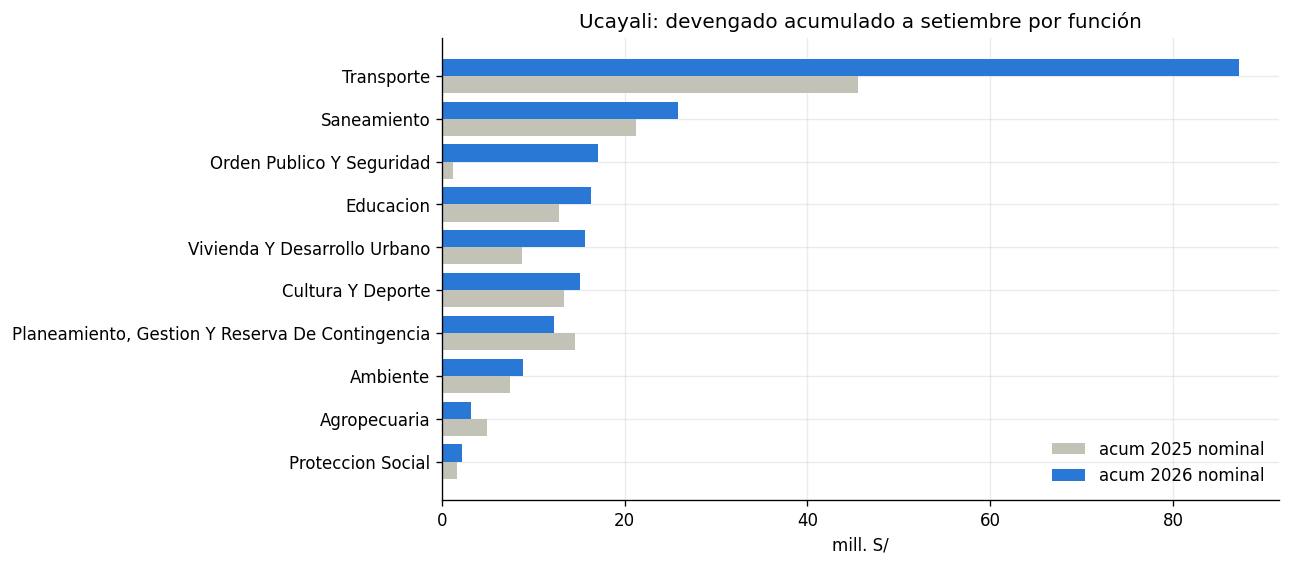

Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/f2_acumulado_funcion_Ucayali_202609.png


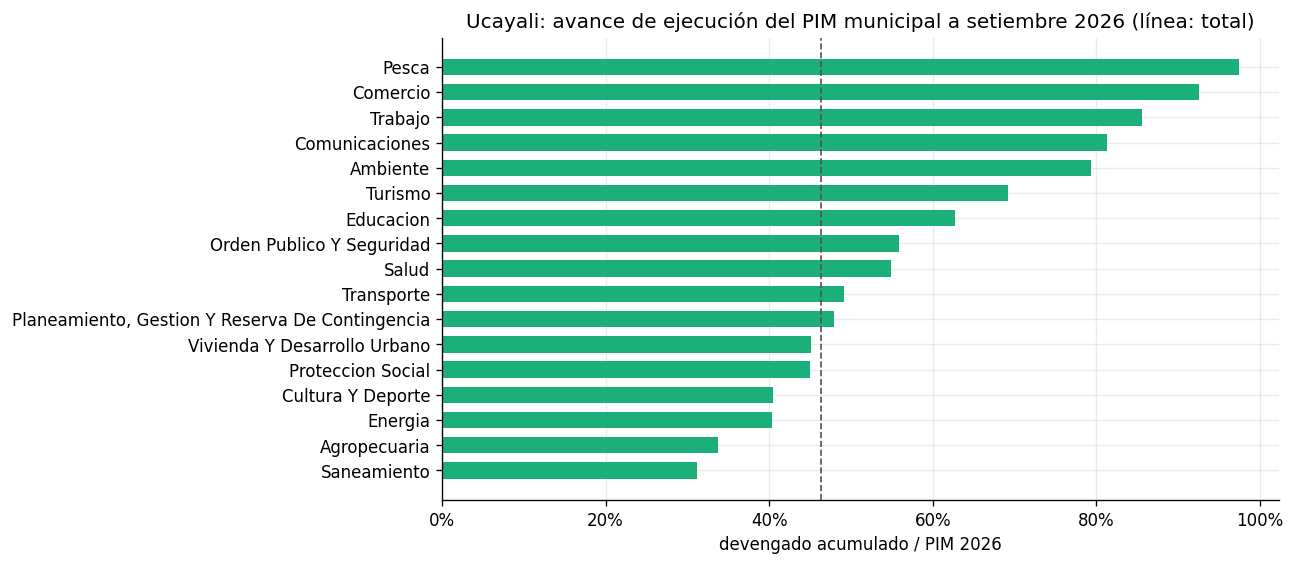

Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/f3_avance_pim_Ucayali_202609.png


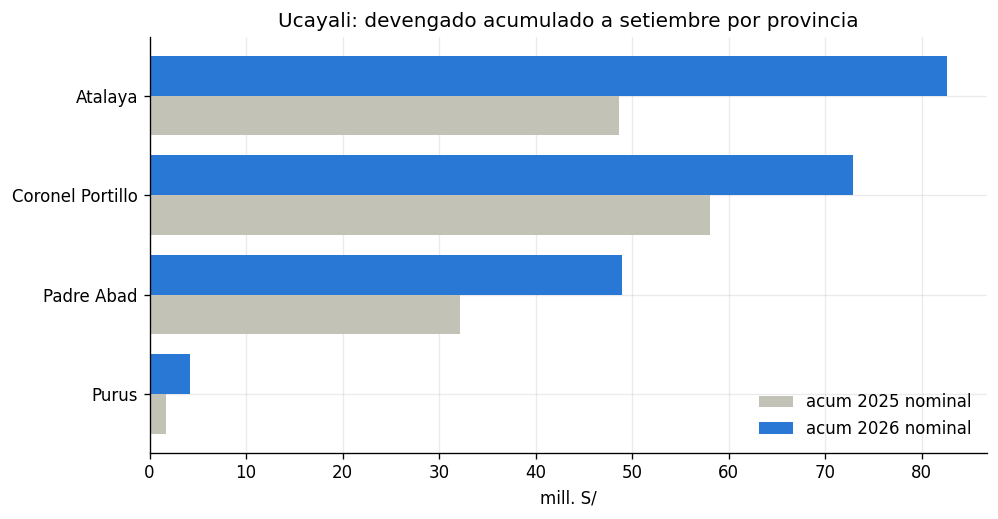

Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/f4_acumulado_provincia_Ucayali_202609.png


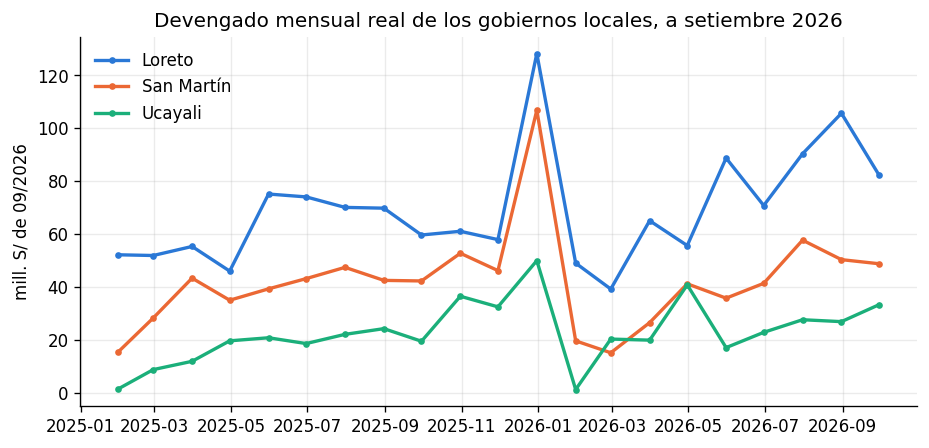

Guardado: /content/drive/My Drive/Fiscal/Procesamiento/output/f5_consolidado_real_202609.png

Listo. Outputs en: /content/drive/My Drive/Fiscal/Procesamiento/output
 - Fiscal_Consolidado_202609.xlsx
 - Fiscal_Loreto_202609.xlsx
 - Fiscal_SanMartin_202609.xlsx
 - Fiscal_Ucayali_202609.xlsx
 - REPORTE_202609.txt
 - f1_mensual_Loreto_202609.png
 - f1_mensual_SanMartin_202609.png
 - f1_mensual_Ucayali_202609.png
 - f2_acumulado_funcion_Loreto_202609.png
 - f2_acumulado_funcion_SanMartin_202609.png
 - f2_acumulado_funcion_Ucayali_202609.png
 - f3_avance_pim_Loreto_202609.png
 - f3_avance_pim_SanMartin_202609.png
 - f3_avance_pim_Ucayali_202609.png
 - f4_acumulado_provincia_Loreto_202609.png
 - f4_acumulado_provincia_SanMartin_202609.png
 - f4_acumulado_provincia_Ucayali_202609.png
 - f5_consolidado_real_202609.png
 - panel_devengado_municipal.csv


In [24]:
# 8. Gráficos
PAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True, 'figure.dpi': 120})
titulo_mes = f'{MESES_ES[FECHA.month-1]} {FECHA.year}'

def guarda(fig, nombre):
    p = os.path.join(PROC_OUT, f'{nombre}_{TAG}.png')
    fig.savefig(p, bbox_inches='tight'); plt.show(); plt.close(fig); print('Guardado:', p)

for dkey, dname in DEPARTAMENTOS.items():
    res = resultados[dkey]; dtag = dname.replace(' ', '').replace('í', 'i')
    # f1: evolución mensual nominal vs real
    t = res['Mensual total']
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(t.index, t.iloc[:, 0], color=PAL[0], lw=2, marker='o', ms=3, label='Nominal')
    ax.plot(t.index, t.iloc[:, 1], color=PAL[1], lw=2, marker='o', ms=3, label=t.columns[1].capitalize())
    ax.set_ylabel('mill. S/'); ax.legend(frameon=False)
    ax.set_title(f'{dname}: devengado mensual de los gobiernos locales, a {titulo_mes}')
    guarda(fig, f'f1_mensual_{dtag}')
    # f2: acumulado por función, año actual vs anterior (top 10)
    a = res['Acumulado por funcion'].head(10).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 5)); y = np.arange(len(a))
    ax.barh(y - 0.2, a.iloc[:, 0], height=0.4, color='#c3c2b7', label=a.columns[0])
    ax.barh(y + 0.2, a.iloc[:, 1], height=0.4, color=PAL[0], label=a.columns[1])
    ax.set_yticks(y); ax.set_yticklabels(a.index); ax.set_xlabel('mill. S/'); ax.legend(frameon=False)
    ax.set_title(f'{dname}: devengado acumulado a {MESES_ES[FECHA.month-1]} por función')
    guarda(fig, f'f2_acumulado_funcion_{dtag}')
    # f3: avance PIM por función
    if 'Avance PIM por funcion' in res:
        av = res['Avance PIM por funcion'].drop(index='TOTAL').sort_values('avance %').dropna(subset=['avance %'])
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.barh(av.index, av['avance %'], color=PAL[2], height=0.65)
        ax.axvline(res['Avance PIM por funcion'].loc['TOTAL', 'avance %'], color='#52514e', ls='--', lw=1)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter()); ax.set_xlabel(f'devengado acumulado / PIM {FECHA.year}')
        ax.set_title(f'{dname}: avance de ejecución del PIM municipal a {titulo_mes} (línea: total)')
        guarda(fig, f'f3_avance_pim_{dtag}')
    # f4: acumulado por provincia
    pv = res['Acumulado por provincia'].iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 4.5)); y = np.arange(len(pv))
    ax.barh(y - 0.2, pv.iloc[:, 0], height=0.4, color='#c3c2b7', label=pv.columns[0])
    ax.barh(y + 0.2, pv.iloc[:, 1], height=0.4, color=PAL[0], label=pv.columns[1])
    ax.set_yticks(y); ax.set_yticklabels(pv.index); ax.set_xlabel('mill. S/'); ax.legend(frameon=False)
    ax.set_title(f'{dname}: devengado acumulado a {MESES_ES[FECHA.month-1]} por provincia')
    guarda(fig, f'f4_acumulado_provincia_{dtag}')

# consolidado: los tres departamentos en términos reales
fig, ax = plt.subplots(figsize=(9, 4))
for i, (dkey, dname) in enumerate(DEPARTAMENTOS.items()):
    s = consol['Mensual real'][dkey]
    ax.plot(s.index, s.values, color=PAL[i], lw=2, marker='o', ms=3, label=dname)
ax.set_ylabel(f'mill. S/ de {BASE:%m/%Y}'); ax.legend(frameon=False)
ax.set_title(f'Devengado mensual real de los gobiernos locales, a {titulo_mes}')
guarda(fig, 'f5_consolidado_real')

print('\nListo. Outputs en:', PROC_OUT)
for n in sorted(os.listdir(PROC_OUT)):
    print(' -', n)